In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Load dataset
df = pd.read_csv("car data.csv")
df.head()



,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
# Check shape and missing values
print("Shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())
print("\nBasic statistics:")
df.describe()

Shape: (301, 9)

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Basic statistics:


,Year,Selling_Price,Present_Price,Driven_kms,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.642584,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


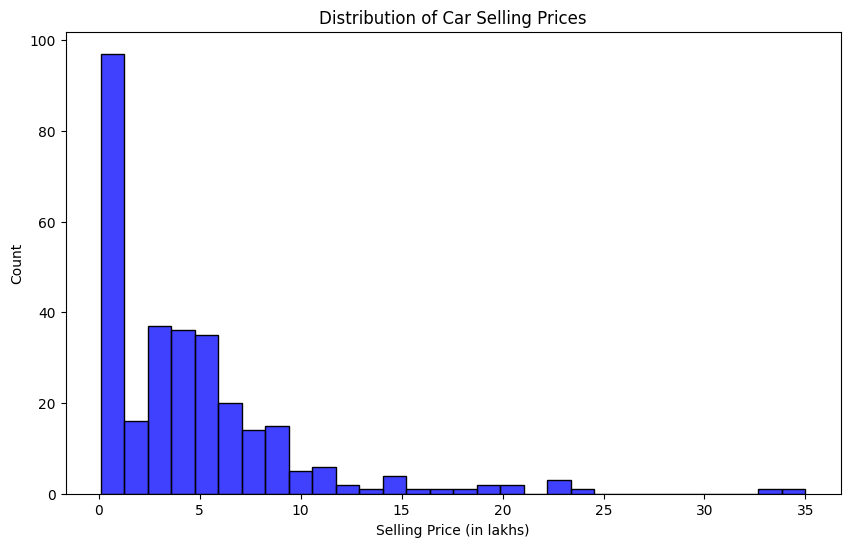

In [7]:
# Visualize selling price distribution
plt.figure(figsize=(10, 6))
sns.histplot(df['Selling_Price'], bins=30, color='blue')
plt.title('Distribution of Car Selling Prices')
plt.xlabel('Selling Price (in lakhs)')
plt.ylabel('Count')
plt.show()

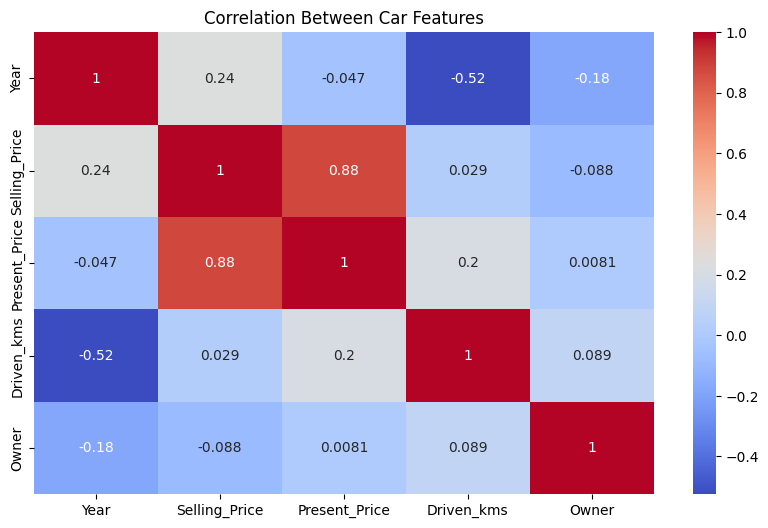

In [8]:
# Correlation heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlation Between Car Features')
plt.show()

In [9]:
# Feature engineering - convert categorical to numerical
df['Fuel_Type'] = df['Fuel_Type'].map({'Petrol': 0, 'Diesel': 1, 'CNG': 2})
df['Selling_type'] = df['Selling_type'].map({'Dealer': 0, 'Individual': 1})
df['Transmission'] = df['Transmission'].map({'Manual': 0, 'Automatic': 1})

# Add car age feature
df['Car_Age'] = 2024 - df['Year']

print("Feature engineering done!")
df.head()

Feature engineering done!


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,0,0,0,0,10
1,sx4,2013,4.75,9.54,43000,1,0,0,0,11
2,ciaz,2017,7.25,9.85,6900,0,0,0,0,7
3,wagon r,2011,2.85,4.15,5200,0,0,0,0,13
4,swift,2014,4.60,6.87,42450,1,0,0,0,10


In [10]:
# Prepare features and target
X = df.drop(['Car_Name', 'Year', 'Selling_Price'], axis=1)
y = df['Selling_Price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
# Evaluate the model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", round(mae, 2))
print("R2 Score:", round(r2, 2))
print("Model Accuracy:", round(r2 * 100, 2), "%")

Mean Absolute Error: 0.65
R2 Score: 0.96
Model Accuracy: 95.83 %


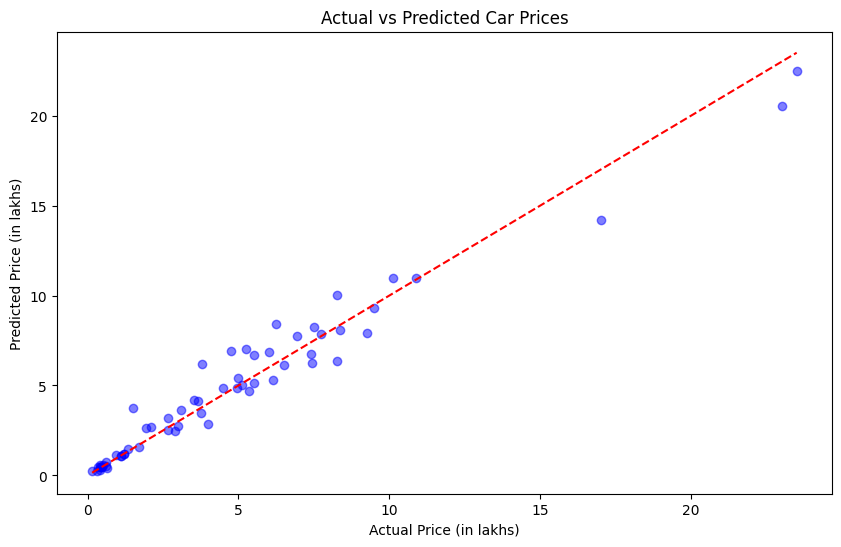

In [12]:
# Actual vs Predicted prices
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Car Prices')
plt.xlabel('Actual Price (in lakhs)')
plt.ylabel('Predicted Price (in lakhs)')
plt.show()

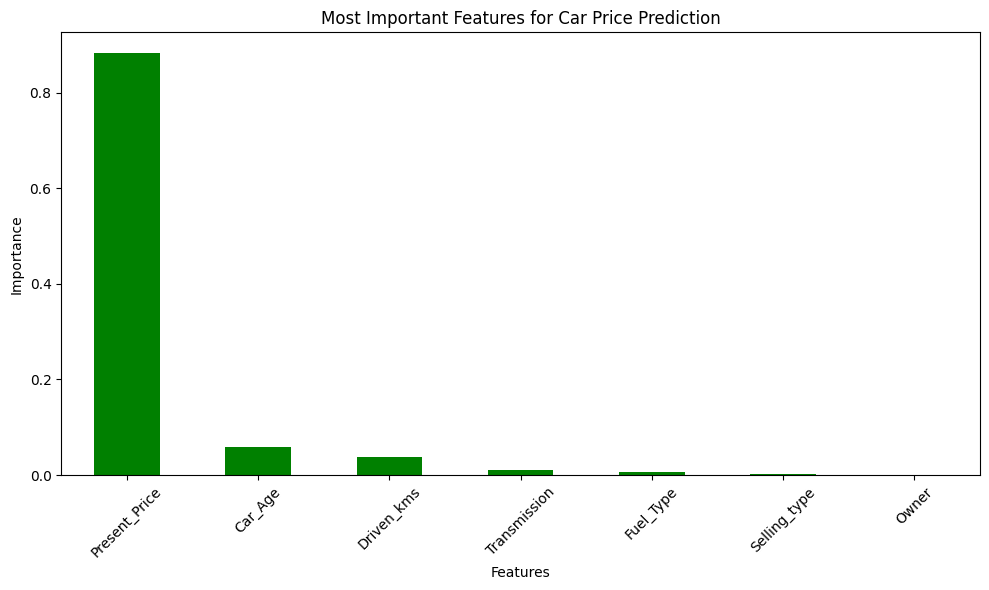

In [13]:
# Feature importance
plt.figure(figsize=(10, 6))
feature_importance = pd.Series(model.feature_importances_, index=X.columns)
feature_importance.sort_values(ascending=False).plot(kind='bar', color='green')
plt.title('Most Important Features for Car Price Prediction')
plt.xlabel('Features')
plt.ylabel('Importance')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [14]:
# Predict price of a new car
new_car = pd.DataFrame([[9.85, 6900, 1, 0, 0, 0, 7]], 
            columns=['Present_Price', 'Driven_kms', 'Fuel_Type', 
                    'Selling_type', 'Transmission', 'Owner', 'Car_Age'])

predicted_price = model.predict(new_car)
print("Predicted Selling Price: ₹", round(predicted_price[0], 2), "lakhs")

Predicted Selling Price: ₹ 7.9 lakhs
